In [44]:
import pandas as pd 
df_housing = pd.read_csv(r"C:\Users\Student\Downloads\OISIS ONLYBYTE\House Price Prediction Dataset.csv")
df_housing

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [45]:
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [46]:
df_housing.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


# Likely predictors are 'Area', 'Location', 'Condition', and the number of bedrooms. I will choose Area becaouse if we can notice the first 2 rows the houses are almost similler but the area is different and also the 'Year Built' is not the same, the first one was built in 1970  and its price is lower than the 1958 house

In [47]:
df_housing.isnull().any()

Id           False
Area         False
Bedrooms     False
Bathrooms    False
Floors       False
YearBuilt    False
Location     False
Condition    False
Garage       False
Price        False
dtype: bool

# One-Hot Encoding for categorical features

In [48]:
df_housing = pd.get_dummies(df_housing, columns=['Location', 'Condition', 'Garage'], drop_first=True)
df_housing

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,295620,False,True,False,False,False,True,False
1996,1997,3046,5,2,1,2019,580929,False,True,False,False,False,True,True
1997,1998,1062,5,1,2,1903,476925,True,False,False,False,False,True,False
1998,1999,4062,3,1,2,1936,161119,False,False,True,False,False,False,True


# YearBuilt to Age

In [49]:
df_housing['Age'] = 2026 - df_housing['YearBuilt']
df_housing = df_housing.drop('YearBuilt', axis = 1)
df_housing

,Id,Area,Bedrooms,Bathrooms,Floors,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes,Age
0,1,1360,5,4,3,149919,False,False,False,False,False,False,False,56
1,2,4272,5,4,3,424998,False,False,False,False,False,False,False,68
2,3,3592,2,2,3,266746,False,False,False,False,True,False,False,88
3,4,966,4,2,2,244020,False,True,False,True,False,False,True,124
4,5,4926,1,4,2,636056,False,False,False,True,False,False,True,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,295620,False,True,False,False,False,True,False,103
1996,1997,3046,5,2,1,580929,False,True,False,False,False,True,True,7
1997,1998,1062,5,1,2,476925,True,False,False,False,False,True,False,123
1998,1999,4062,3,1,2,161119,False,False,True,False,False,False,True,90


# Select features (exclude 'Id' and 'Price')

In [50]:
x = df_housing.drop(columns=['Id', 'Price'])
y = df_housing['Price']

# Correlation Heatmap

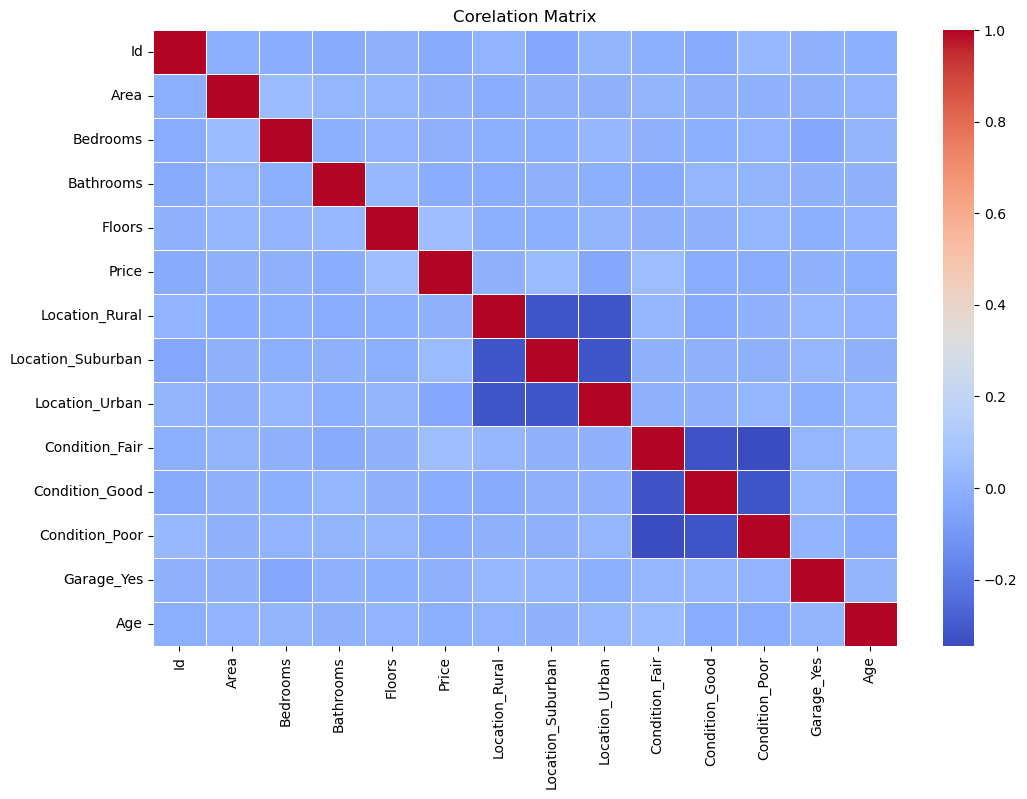

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
corr = df_housing.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths = 0.5)
plt.title('Corelation Matrix')
plt.show()

In [52]:
# Spliting data into train and test data 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size = 0.8, test_size = 0.2, random_state =42)

# Scale numeric features 

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns = x.columns)

In [54]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
lm.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = lm.predict(x_test)

In [61]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
r2_score_test = r2_score(y_test, y_pred)
print(f"R2: {r2_score_test:,.2f}")
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:,.2f}")
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:,.2f}")

R2: -0.01
MSE: 78,321,466,146.03
RMSE: 279,859.73


# Actual vs Predicted

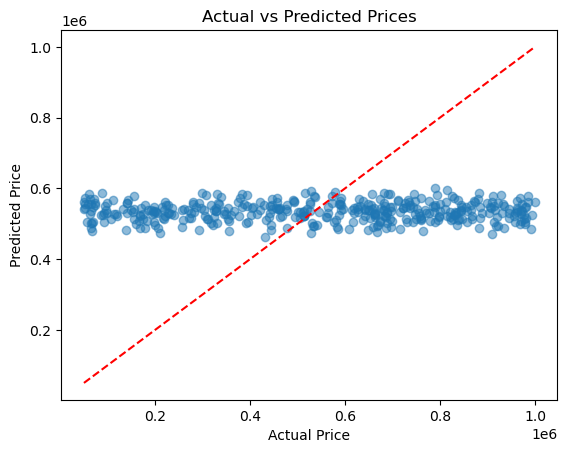

In [62]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

# Residual Plot

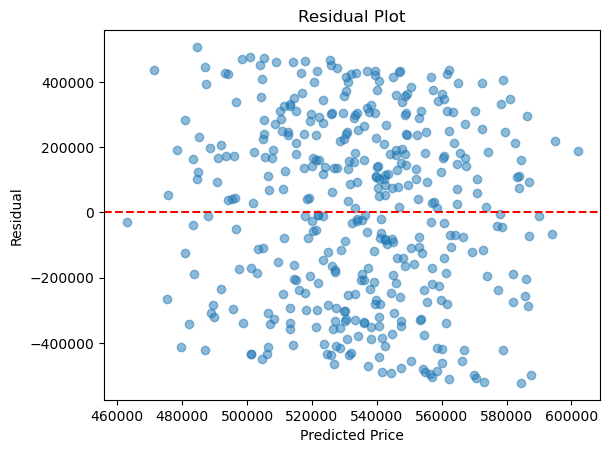

In [63]:
residual = y_test.values - y_pred
plt.scatter(y_pred, residual, alpha = 0.5)
plt.axhline(y = 0, color = 'r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

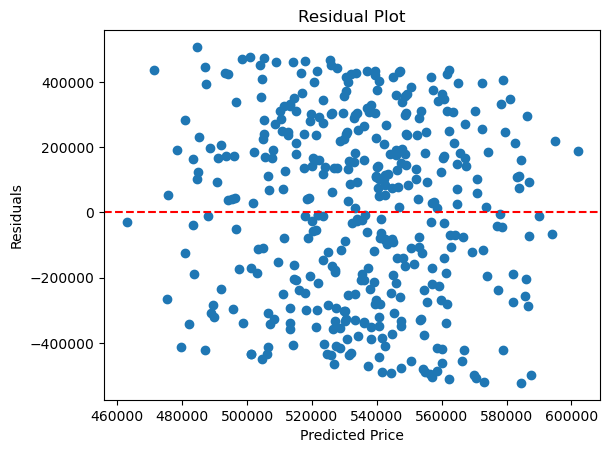

In [64]:
import matplotlib.pyplot as plt
plt.scatter(y_pred, residual)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

# Coefficient analysis

In [65]:
df_housing.corr()[['Price']]

,Price
Id,-0.025643
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Floors,0.055890
Price,1.000000
Location_Rural,0.001890
Location_Suburban,0.040303
Location_Urban,-0.038312
Condition_Fair,0.049218


In [66]:
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': lm.coef_}).sort_values('Coefficient', ascending = False)
print("\nFeature Impart on Price:")
print(coef_df)


Feature Impart on Price:
              Feature   Coefficient
7      Condition_Fair  24083.307846
3              Floors  23727.983633
5   Location_Suburban  11511.989815
9      Condition_Poor   4073.268930
10         Garage_Yes   2373.530579
4      Location_Rural   1317.542020
1            Bedrooms     76.784827
0                Area     -0.575754
11                Age   -117.613885
2           Bathrooms  -9662.248234
6      Location_Urban -12718.918912
8      Condition_Good -12941.044835


# Ridge & Lsso Comparison

In [67]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
ridge_pred = ridge.predict(x_test)
ridge_r2 = r2_score(y_test, ridge_pred)

lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)
lasso_pred = lasso.predict(x_test)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"Linear Regression R2: {r2_score_test:.4f}")
print(f"Ridge Regression R2: {ridge_r2:.4f}")
print(f"LassoRegression R2: {lasso_r2:.4f}")

Linear Regression R2: -0.0067
Ridge Regression R2: -0.0067
LassoRegression R2: -0.0067
